## 1. Image and DCT Basics

A grayscale image is represented as a matrix of pixel intensities. The Discrete Cosine Transform (DCT) converts a block of image samples into frequency coefficients.

For an $8 \times 8$ block, the 2D DCT is given by

$$F(u,v)=\frac{1}{4}C(u)C(v)\sum_{x=0}^{7}\sum_{y=0}^{7}f(x,y)\cos\left(\frac{(2x+1)u\pi}{16}\right)\cos\left(\frac{(2y+1)v\pi}{16}\right)$$

where

$$C(k)=\begin{cases}\frac{1}{\sqrt{2}}, & k=0 \\ 1, & k>0\end{cases}$$

In [ ]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import math

## 2. Reading and Preprocessing the Image

The image is loaded and converted to grayscale so that it becomes a 2D matrix of intensity values. This step prepares the image for block-based transformation.

$$I \in \mathbb{R}^{M \times N}$$

where $M$ and $N$ are the image height and width.

In [ ]:
# 1. Read image and convert to grayscale
image = Image.open("cat.png").convert("L")
img = np.array(image, dtype=np.float64)

print("Original image shape:", img.shape)


Original image shape: (758, 510)


## 3. Padding the Image

To divide the image into $8 \times 8$ blocks, the dimensions are adjusted to the nearest multiple of 8.

If the original size is $(H,W)$, then the padded size is

$$H' = 8\left\lceil \frac{H}{8} \right\rceil, \qquad W' = 8\left\lceil \frac{W}{8} \right\rceil$$

Padding ensures that each block has a complete size for transformation.

In [ ]:
# 2. Pad image so dimensions are multiples of 8
height, width = img.shape

new_height = ((height + 7) // 8) * 8
new_width = ((width + 7) // 8) * 8

padded = np.zeros((new_height, new_width))

padded[:height, :width] = img

print("Padded image shape:", padded.shape)

Padded image shape: (760, 512)


## 4. Quantization Matrix

Quantization reduces the precision of DCT coefficients. The JPEG-style quantization matrix $Q$ is used to divide the coefficients, which helps remove less important high-frequency components.

$$F_q(u,v)=\left\lfloor \frac{F(u,v)}{Q(u,v)} \right\rceil$$

This step is the main source of compression.

In [ ]:
# 3. Quantization Matrix
Q = np.array([
    [16, 11, 10, 16, 24, 40, 51, 61],
    [12, 12, 14, 19, 26, 58, 60, 55],
    [14, 13, 16, 24, 40, 57, 69, 56],
    [14, 17, 22, 29, 51, 87, 80, 62],
    [18, 22, 37, 56, 68, 109, 103, 77],
    [24, 35, 55, 64, 81, 104, 113, 92],
    [49, 64, 78, 87, 103, 121, 120, 101],
    [72, 92, 95, 98, 112, 100, 103, 99]
], dtype=np.float64)

## 5. Normalization Constant

The normalization constant $C(k)$ is used in the DCT formula to ensure correct scaling at the DC term.

$$C(k)=\begin{cases}\frac{1}{\sqrt{2}}, & k=0 \\ 1, & k>0\end{cases}$$

This helps make the transform orthogonal and energy-preserving.

In [ ]:
# 4. Function to calculate C(u)
def C(value):
    if value == 0:
        return 1 / math.sqrt(2)
    else:
        return 1

## 6. Forward DCT Implementation

This cell implements the forward 2D DCT manually. The transform converts a spatial block into frequency coefficients by summing weighted cosine terms.

$$F(u,v)=\frac{1}{4}C(u)C(v)\sum_{x=0}^{7}\sum_{y=0}^{7}f(x,y)\cos\left(\frac{(2x+1)u\pi}{16}\right)\cos\left(\frac{(2y+1)v\pi}{16}\right)$$

In [ ]:
# 5. DCT Function - implemented manually
def dct_2d(block):

    result = np.zeros((8, 8))

    for u in range(8):
        for v in range(8):

            total = 0

            for x in range(8):
                for y in range(8):

                    cos1 = math.cos(
                        ((2 * x + 1) * u * math.pi) / 16
                    )

                    cos2 = math.cos(
                        ((2 * y + 1) * v * math.pi) / 16
                    )

                    total += block[x, y] * cos1 * cos2

            result[u, v] = (
                0.25 *
                C(u) *
                C(v) *
                total
            )

    return result

## 7. Inverse DCT Implementation

The inverse DCT reconstructs the block from its frequency coefficients. It uses the same cosine basis functions in reverse.

$$f(x,y)=\frac{1}{4}\sum_{u=0}^{7}\sum_{v=0}^{7}C(u)C(v)F(u,v)\cos\left(\frac{(2x+1)u\pi}{16}\right)\cos\left(\frac{(2y+1)v\pi}{16}\right)$$

In [ ]:
# 6. IDCT Function - implemented manually
def idct_2d(block):

    result = np.zeros((8, 8))

    for x in range(8):
        for y in range(8):

            total = 0

            for u in range(8):
                for v in range(8):

                    cos1 = math.cos(
                        ((2 * x + 1) * u * math.pi) / 16
                    )

                    cos2 = math.cos(
                        ((2 * y + 1) * v * math.pi) / 16
                    )

                    total += (
                        C(u) *
                        C(v) *
                        block[u, v] *
                        cos1 *
                        cos2
                    )

            result[x, y] = 0.25 * total

    return result

## 8. Block Processing and Reconstruction

Each image block is transformed, quantized, dequantized, and reconstructed. This is the core of the JPEG-style compression pipeline.

$$F_q(u,v)=\left\lfloor \frac{F(u,v)}{Q(u,v)} \right\rceil, \qquad F'(u,v)=F_q(u,v)Q(u,v)$$

In [ ]:
# 7. Process every 8x8 block
compressed = np.zeros_like(padded)
reconstructed = np.zeros_like(padded)

for i in range(0, new_height, 8):

    for j in range(0, new_width, 8):

        # Get 8x8 block
        block = padded[i:i+8, j:j+8]

        # Level shifting
        # Convert [0,255] -> [-128,127]
        block_shifted = block - 128

        # Apply DCT
        dct_block = dct_2d(block_shifted)

        # Quantization
        quantized = np.round(dct_block / Q)

        # Store quantized coefficients
        compressed[i:i+8, j:j+8] = quantized

        # Dequantization
        dequantized = quantized * Q

        # Apply IDCT
        idct_block = idct_2d(dequantized)

        # Reverse level shifting
        reconstructed[i:i+8, j:j+8] = idct_block + 128

## 9. Removing Padding

After reconstruction, the image is cropped back to its original size by removing the padded border.

$$I_{rec} = I_{pad}[0:H, 0:W]$$

This restores the output image to its original dimensions.

In [ ]:
# 8. Remove padding
reconstructed = reconstructed[:height, :width]

## 10. Clipping the Reconstructed Values

The reconstructed pixel values are clipped to the valid image range $[0,255]$ to avoid out-of-range intensities after the inverse transform.

$$p_{out} = \min(255, \max(0, p_{rec}))$$

This keeps the image displayable and consistent.

In [ ]:
# 9. Clip values to valid image range
reconstructed = np.clip(
    reconstructed,
    0,
    255
)

## 11. Saving the Reconstructed Image

The reconstructed image is saved as an output file so the result can be reviewed outside the notebook.

This step finalizes the compression and reconstruction workflow.

In [11]:
# Convert to uint8
reconstructed = reconstructed.astype(np.uint8)

In [ ]:
# 10. Save compressed/reconstructed image
output = Image.fromarray(reconstructed)

output.save("compressed_image.jpg")

## 12. Visual Comparison

The original and reconstructed images are displayed side by side to evaluate the compression effect visually.

This confirms the practical behavior of the DCT-based approach.

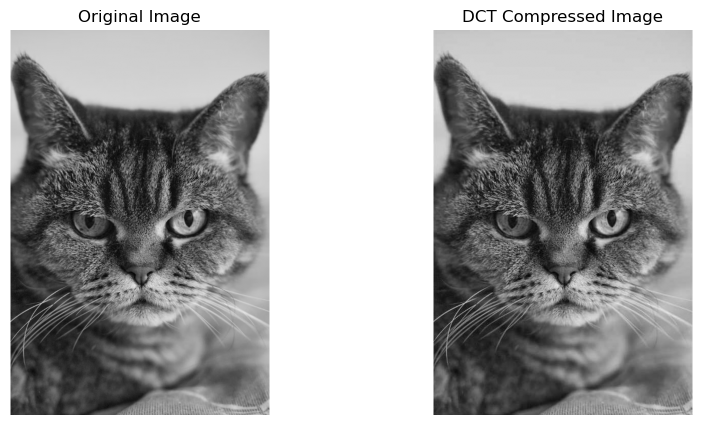

In [ ]:
# 11. Display results
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(img, cmap="gray")
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(reconstructed, cmap="gray")
plt.title("DCT Compressed Image")
plt.axis("off")

plt.show()

## 13. Compression Statistics

The final statistics compare the original image size with the number of retained coefficients. If the original image uses $8HW$ bits and the compressed representation uses $k\times 8$ bits, then the compression ratio is

$$R = \frac{8HW}{8k} = \frac{HW}{k}$$

where $k$ is the number of retained non-zero coefficients.

In [ ]:
# Compression Statistics

# Original image has 8 bits per pixel
original_bits = height * width * 8

# Count non-zero quantized DCT coefficients
non_zero_coefficients = np.count_nonzero(compressed)

# Assume each quantized coefficient is stored using 8 bits
compressed_bits = non_zero_coefficients * 8

# Compression ratio
compression_ratio = original_bits / compressed_bits

# Percentage of coefficients removed
zero_coefficients = compressed.size - non_zero_coefficients

zero_percentage = (
    zero_coefficients / compressed.size
) * 100

print("\n========== Compression Statistics ==========")

print("Original Image Size (bits):", original_bits)

print("Non-zero DCT Coefficients:",
      non_zero_coefficients)

print("Zero DCT Coefficients:",
      zero_coefficients)

print("Compressed Size (bits):",
      compressed_bits)

print("Compression Ratio:",
      round(compression_ratio, 2), ":1")

print("Compression Percentage:",
      round(zero_percentage, 2), "%")


========== Compression Statistics ==========
Original Image Size (bits): 3092640
Non-zero DCT Coefficients: 57634
Zero DCT Coefficients: 331486
Compressed Size (bits): 461072
Compression Ratio: 6.71 :1
Compression Percentage: 85.19 %
